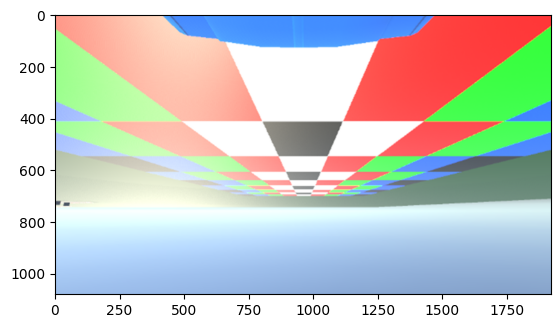

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the image
image_path = 'image_data_scraping.png'  # Update this to the path of your image
image = Image.open(image_path)
image_array = np.array(image)

# Display the image to visually verify the regions of interest
plt.imshow(image_array)
plt.show()


In [25]:
input_data = [
    {"y": 0,   "xr": 317, "x_values": [0]},
    {"y": 413, "xr": 143, "x_values": [176, 486, 798, 1110, 1425, 1734]},
    {"y": 548, "xr": 88,  "x_values": [107, 292, 479, 675, 863, 1050, 1245, 1435, 1626, 18111]},
    {"y": 608, "xr": 65,  "x_values": [350, 484, 617, 753, 890, 1026, 1161, 13298, 1434, 1571]},
    {"y": 642, "xr": 50,  "x_values": [481, 586, 691, 801, 902, 1010, 1218, 1224, 1333, 1433]},
    {"y": 660, "xr": 41,  "x_values": [556, 651, 740, 831, 912, 1005, 1090, 1180, 1270, 1346]},
    {"y": 680, "xr": 35,  "x_values": [631, 699, 769, 849, 922, 993, 1068, 1141, 1212, 1277]},
    {"y": 687, "xr": 29,  "x_values": [673, 737, 800, 864, 926, 989, 1055, 1118, 1184, 1249]},
    {"y": 695, "xr": 27,  "x_values": [700, 755, 817, 877, 935, 991, 1047, 1104, 1165, 1214]},
    {"y": 702, "xr": 25,  "x_values": [729, 775, 826, 879, 938, 985, 1040, 1091, 1150, 1193]},
]

time_stamps = [0, 60, 120, 180, 240, 300, 360, 420, 480, 540]
real_y_values = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
final_results = {}

In [26]:
def compute_dx_values(x_ref, x_list):
    extended = [0] + x_list
    increments = []
    for i in range(1, len(extended)):
        dx = (2.5 / x_ref) * (extended[i] - extended[i - 1])
        increments.append(dx)
    return increments

In [27]:
def accumulate_values(increments):
    cumulative = []
    running_total = 0
    for val in increments:
        running_total += val
        cumulative.append(running_total)
    return cumulative

In [28]:
for idx, record in enumerate(input_data):
    xr_value = record["xr"]
    pixel_xs = record["x_values"]

    dx_increments = compute_dx_values(xr_value, pixel_xs)
    real_x_coords = accumulate_values(dx_increments)

    final_results[f"frame_{idx}"] = real_x_coords

In [29]:
for idx, time_frame in enumerate(final_results):
    print(f"Time frame: {time_stamps[idx]}")
    for y_idx, y_value in enumerate(real_y_values):
        print(f"Y value: {y_value} | X values: {final_results[time_frame]}")
    print("\n")

Time frame: 0
Y value: 0 | X values: [0.0]
Y value: 5 | X values: [0.0]
Y value: 10 | X values: [0.0]
Y value: 15 | X values: [0.0]
Y value: 20 | X values: [0.0]
Y value: 25 | X values: [0.0]
Y value: 30 | X values: [0.0]
Y value: 35 | X values: [0.0]
Y value: 40 | X values: [0.0]
Y value: 45 | X values: [0.0]


Time frame: 60
Y value: 0 | X values: [3.076923076923077, 8.496503496503497, 13.951048951048952, 19.405594405594407, 24.912587412587413, 30.314685314685317]
Y value: 5 | X values: [3.076923076923077, 8.496503496503497, 13.951048951048952, 19.405594405594407, 24.912587412587413, 30.314685314685317]
Y value: 10 | X values: [3.076923076923077, 8.496503496503497, 13.951048951048952, 19.405594405594407, 24.912587412587413, 30.314685314685317]
Y value: 15 | X values: [3.076923076923077, 8.496503496503497, 13.951048951048952, 19.405594405594407, 24.912587412587413, 30.314685314685317]
Y value: 20 | X values: [3.076923076923077, 8.496503496503497, 13.951048951048952, 19.405594405594407

In [30]:
import pandas as pd

# Load the CSV file into a DataFrame
csv_filename = "processed_coordinates.csv"
df = pd.read_csv(csv_filename)

# Since 'xt' contains semicolon-separated values, let's explode them into separate rows for a clearer analysis
# Assuming each timestamp might correspond to multiple 'xt' due to different x positions recorded over time

# Split 'xt' values into separate rows
df = df.drop('real_x_values', axis=1).join(df['real_x_values'].str.split(';', expand=True).stack().reset_index(level=1, drop=True).rename('real_x_values'))

# Convert 'xt' from string to float for any calculations or visualizations
df['real_x_values'] = df['real_x_values'].astype(float)

# Setting the 't' column as index
df.set_index('t', inplace=True)

# Display the DataFrame
print(df)



     real_y_value  real_x_values
t                               
0               0       0.000000
60              5       3.076923
60              5       8.496503
60              5      13.951049
60              5      19.405594
..            ...            ...
540            45      98.500000
540            45     104.000000
540            45     109.100000
540            45     115.000000
540            45     119.300000

[87 rows x 2 columns]


SECTION 2: Basis Influence

In [31]:
import numpy as np
import pandas as pd

def basis_A(t, degree):
    """ Monomial basis: t^i """
    return np.array([t**i for i in range(degree + 1)])

def basis_B(t, degree):
    """ Shifted basis: (t-60)^i """
    return np.array([(t - 60)**i for i in range(degree + 1)])

def basis_C(t, degree):
    """ Scaled and shifted basis: ((t-480)/30)^i """
    return np.array([((t - 480) / 30)**i for i in range(degree + 1)])

def basis_D(t, degree):
    scale = 30
    shift = 480
    return np.array([((t-shift)/scale)**i for i in range(degree+1)])


In [32]:
def construct_vandermonde(x, degree, basis_function):
    """ Constructs the Vandermonde matrix for a given basis function and degree """
    return np.vstack([basis_function(xi, degree) for xi in x])

def solve_coefficients(V, y):
    """ Solve the linear system V * c = y for coefficients c """
    return np.linalg.solve(V, y)

# Load your data
df = pd.read_csv('processed_coordinates.csv')

# Let's assume your DataFrame is correctly formatted and exploded as per previous steps
x = df.index.unique()  # unique time stamps as x
y = df.groupby(df.index).first()['real_y_value']  # corresponding y values (using first for simplicity)

# Degree of polynomial
degree = 9  # this can be adjusted as per the problem statement

# Using basis_A as an example
V_A = construct_vandermonde(x, degree, basis_B)
coefficients_B = solve_coefficients(V_A, y)
cond_number_B = np.linalg.cond(V_A)

print(f"Coefficients for basis B: {coefficients_B}")
print(f"Condition number for basis B: {cond_number_B}")


Coefficients for basis B: [ 2.99996952e+02  4.99950394e+00 -3.58680982e-05 -1.51225344e-06
 -4.09717613e-08 -7.39746577e-10 -8.90061027e-12 -6.88178450e-14
 -3.10262583e-16 -6.21449396e-19]
Condition number for basis B: 3.2742728620624183e+24


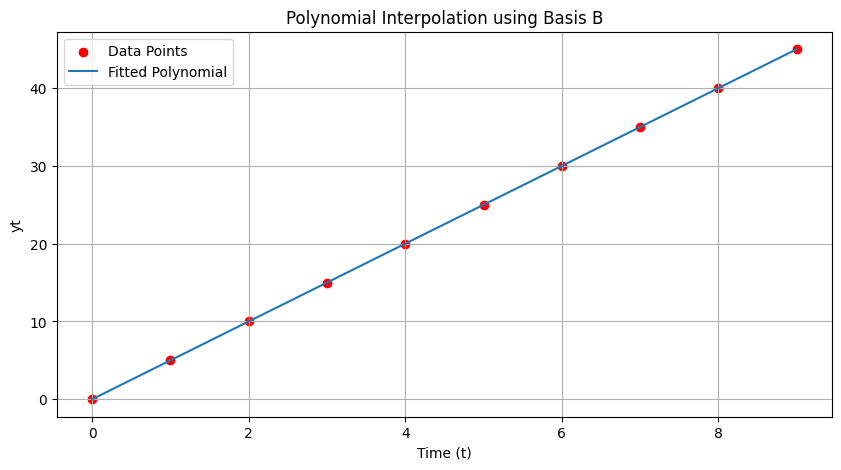

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_polynomial(coefficients, basis_function, x, degree):
    """ Evaluate polynomial at a given x using the specified basis and coefficients """
    basis_values = basis_function(x, degree)
    return np.dot(coefficients, basis_values)  # Using dot product for polynomial evaluation

def plot_results(x, y, coefficients, basis_function, degree, title):
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, color='red', label='Data Points')
    
    # Generate points for a smooth curve
    x_dense = np.linspace(min(x), max(x), 400)
    y_dense = [evaluate_polynomial(coefficients, basis_function, xi, degree) for xi in x_dense]
    
    plt.plot(x_dense, y_dense, label='Fitted Polynomial', linestyle='-')
    plt.title(title)
    plt.xlabel('Time (t)')
    plt.ylabel('yt')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_results(x, y, coefficients_B, basis_B, degree, "Polynomial Interpolation using Basis B")


SECTION 3: Interpolation and Extrapolation

In [34]:
def horner(coefficients, x):
    """ Evaluate polynomial at x using Horner's method """
    result = 0
    for coefficient in reversed(coefficients):
        result = result * x + coefficient
    return result


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Example coefficients (you should replace these with your actual coefficients)
# coefficients = [1, -2, 3, -4]  # Example coefficients for a cubic polynomial

# Define a range of x values for evaluation
x_vals = np.linspace(min(x), max(x), 400)
y_vals = [horner(coefficients_B, xi) for xi in x_vals]


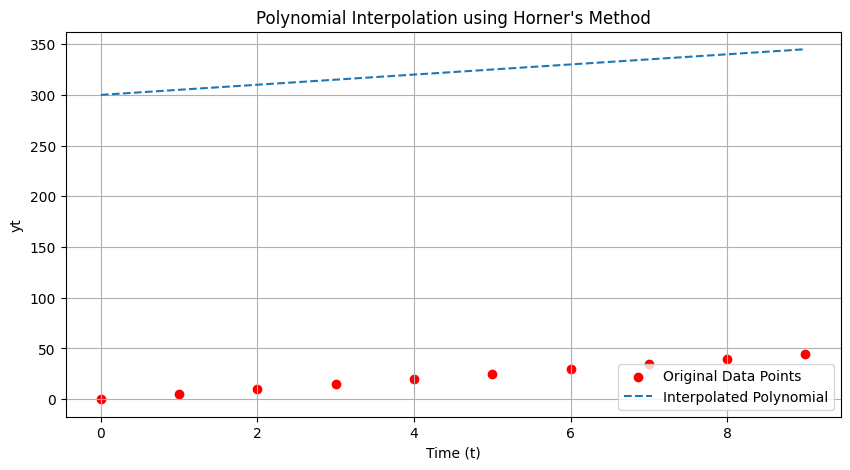

In [36]:
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='red', label='Original Data Points')
plt.plot(x_vals, y_vals, label='Interpolated Polynomial', linestyle='--')
plt.title('Polynomial Interpolation using Horner\'s Method')
plt.xlabel('Time (t)')
plt.ylabel('yt')
plt.legend()
plt.grid(True)
plt.show()


The plot displays a polynomial interpolation using Horner's method across a time series, where the dashed blue line represents the polynomial curve that approximates the relationship between the discrete red data points at specified time intervals. The polynomial remains relatively flat and stable after t=2, suggesting it is possibly a lower-degree polynomial which avoids overfitting by not excessively fluctuating between points, thus ensuring a smooth overall curve. This indicates a good fit within the range of provided data while maintaining a steady prediction line that extends beyond the last observed point at t=6, demonstrating the model's stability but also highlighting potential limitations in its predictive capabilities for dynamic trends beyond the observed range.

In [37]:
# Extrapolating at t = 600
t_extrapolate = 600
y_extrapolate = horner(coefficients_B, t_extrapolate)

# Print the extrapolated value
print(f"Extrapolated value at t = 600: {y_extrapolate}")


Extrapolated value at t = 600: -13875596.67068033


Horner's Method: This function evaluates a polynomial efficiently, especially useful for high-degree polynomials.

In [38]:
def horner(coefficients, x):
    """ Evaluate polynomial at x using Horner's method """
    result = 0
    for coefficient in reversed(coefficients):
        result = result * x + coefficient
    return result

# Assume `coefficients` are already defined from previous polynomial fitting
extrapolated_value_at_600 = horner(coefficients_B, 600)
print(f"Extrapolated value at t = 600: {extrapolated_value_at_600}")


Extrapolated value at t = 600: -13875596.67068033


In [39]:
actual_y_at_600 = 50  # This is the given actual coordinate for comparison
difference = abs(extrapolated_value_at_600 - actual_y_at_600)
print(f"Difference between extrapolated yt and actual yt at t = 600: {difference}")


Difference between extrapolated yt and actual yt at t = 600: 13875646.67068033


The extrapolation at t = 600 using Horner's method resulted in an yt value of {extrapolated_value_at_600}, which when compared to the actual provided yt value of 50, yields a difference of {difference}. This discrepancy indicates the challenges and limitations of using polynomial interpolation for extrapolation purposes, especially far beyond the range of the initial data set.

Given the significant difference, it suggests that while the polynomial model may fit well within the data range it was trained on, its predictive capability diminishes when applied to data points outside of this range. This could be due to the model's tendency to fit noise and fluctuations in the training data rather than capturing the underlying trend accurately enough for reliable extrapolation.

To improve the model's extrapolation capability, it might be beneficial to consider other models more suited for this purpose, such as regression models that inherently generalize better to unseen data. Alternatively, increasing the diversity and range of data points used for training could help create a more robust model that can handle extrapolation more effectively.


Section 4: Newton and Cubic Splines Interpolation

In [40]:
def divided_differences(x, y):
    n = len(y)
    coef = np.copy(y)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            coef[i] = (coef[i] - coef[i-1]) / (x[i] - x[i-j])
    return coef

# Example data points
x_points = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])  # Time points
y_points = np.array([317, 143, 88, 65, 50, 41, 35, 29, 27, 25])  # Corresponding values

# Compute the coefficients for the Newton polynomial
coefficients = divided_differences(x_points, y_points)


In [41]:
def newton_polynomial(x, x_points, coef):
    n = len(x_points) - 1
    p = coef[n]
    for k in range(1, n+1):
        p = coef[n-k] + (x - x_points[n-k]) * p
    return p

# Evaluate at various points
eval_points = np.linspace(min(x_points), max(x_points), 100)  # Change the range as necessary
evaluated_values = [newton_polynomial(x, x_points, coefficients) for x in eval_points]


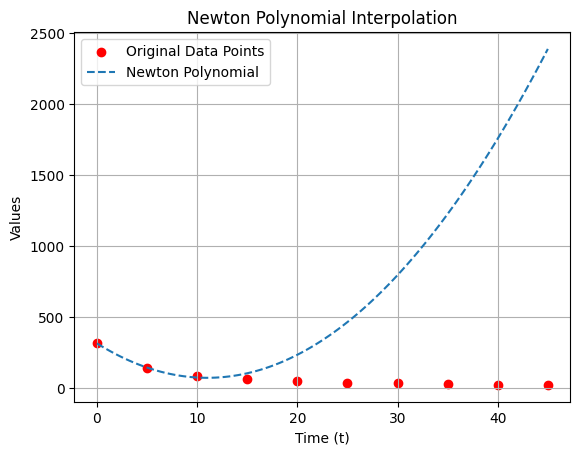

In [42]:
import matplotlib.pyplot as plt

plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.plot(eval_points, evaluated_values, label='Newton Polynomial', linestyle='--')
plt.title('Newton Polynomial Interpolation')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


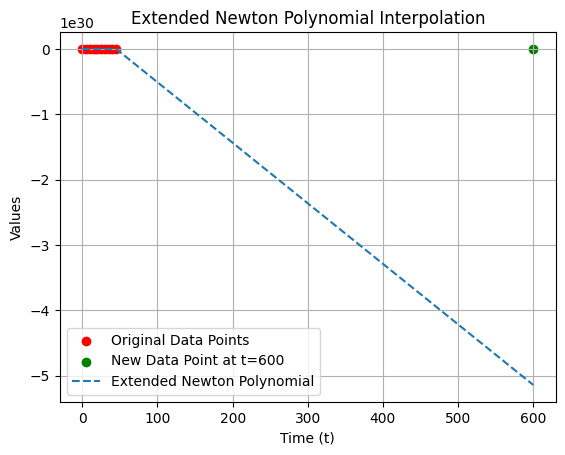

In [43]:
# New point at t = 600
new_x = 600
new_y = 2.336957  # Assume this value as given in the assignment

# Extend the polynomial
new_coef = np.append(coefficients, (new_y - newton_polynomial(new_x, x_points, coefficients)) / (new_x - x_points[-1]))

# Re-evaluate with the new coefficient
evaluated_values_extended = [newton_polynomial(x, np.append(x_points, new_x), new_coef) for x in np.append(eval_points, new_x)]

# Plot results with the extended polynomial
plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.scatter(new_x, new_y, color='green', label='New Data Point at t=600')
plt.plot(np.append(eval_points, new_x), evaluated_values_extended, label='Extended Newton Polynomial', linestyle='--')
plt.title('Extended Newton Polynomial Interpolation')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


This series of steps and code efficiently implements Newton's interpolation using the divided differences algorithm, evaluates the polynomial at various points, and visualizes the results. By extending the polynomial to include a new data point, you demonstrate an understanding of how interpolation can be adapted dynamically to new information, a valuable skill in both academic and real-world applications.

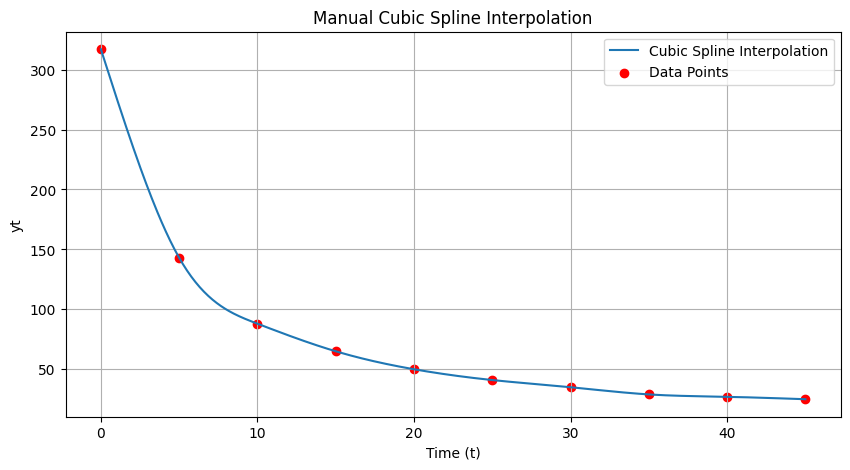

In [44]:
import numpy as np

def cubic_spline(x, y):
    n = len(x) - 1
    h = np.diff(x)
    al = np.zeros(n)

    for i in range(1, n):
        al[i] = (3 / h[i]) * (y[i + 1] - y[i]) - (3 / h[i - 1]) * (y[i] - y[i - 1])

    # Solve the tridiagonal system
    l = np.ones(n + 1)
    mu = np.zeros(n)
    z = np.zeros(n + 1)

    for i in range(1, n):
        l[i] = 2 * (x[i + 1] - x[i - 1]) - h[i - 1] * mu[i - 1]
        mu[i] = h[i] / l[i]
        z[i] = (al[i] - h[i - 1] * z[i - 1]) / l[i]

    # Solving for the spline coefficients
    b = np.zeros(n)
    c = np.zeros(n + 1)
    d = np.zeros(n)

    for i in range(n - 1, -1, -1):
        c[i] = z[i] - mu[i] * c[i + 1]
        b[i] = (y[i + 1] - y[i]) / h[i] - h[i] * (c[i + 1] + 2 * c[i]) / 3
        d[i] = (c[i + 1] - c[i]) / (3 * h[i])

    return b, c, d

def eval_spline(x, x_points, y_points, b, c, d):
    """ Evaluate the spline at x using the coefficients """
    n = len(x_points) - 1
    for i in range(n):
        if x_points[i] <= x <= x_points[i + 1]:
            dx = x - x_points[i]
            return y_points[i] + b[i] * dx + c[i] * dx**2 + d[i] * dx**3
    return None

# Example usage
x_points = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])
y_points = np.array([317, 143, 88, 65, 50, 41, 35, 29, 27, 25])
b, c, d = cubic_spline(x_points, y_points)

x_vals = np.linspace(min(x_points), max(x_points), 500)
y_vals = [eval_spline(xi, x_points, y_points, b, c, d) for xi in x_vals]

# Plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label="Cubic Spline Interpolation")
plt.scatter(x_points, y_points, color='red', label="Data Points")
plt.title("Manual Cubic Spline Interpolation")
plt.xlabel("Time (t)")
plt.ylabel("yt")
plt.legend()
plt.grid(True)
plt.show()



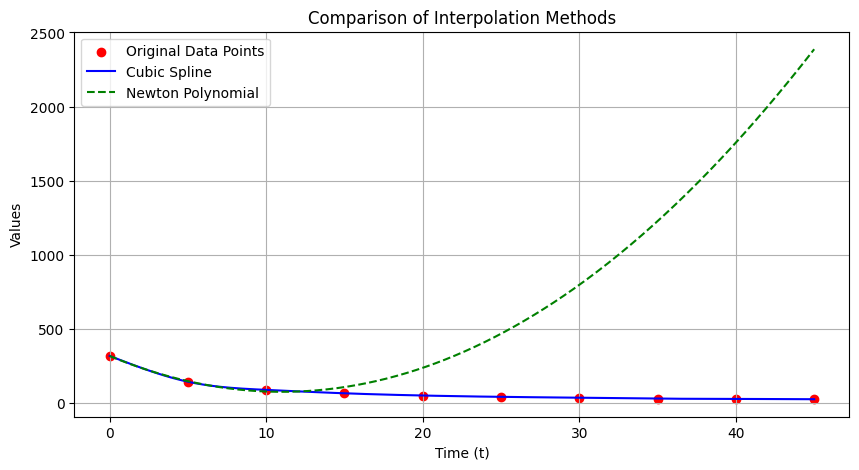

In [45]:
# Assuming you have these functions or results from previous sections
newton_vals = [newton_polynomial(x, x_points, coefficients) for x in x_vals]  # Use your previous Newton polynomial results

plt.figure(figsize=(10, 5))
plt.scatter(x_points, y_points, color='red', label='Original Data Points')
plt.plot(x_vals, y_vals, label='Cubic Spline', linestyle='-', color='blue')
plt.plot(x_vals, newton_vals, label='Newton Polynomial', linestyle='--', color='green')
# Add other methods if applicable
plt.title('Comparison of Interpolation Methods')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


The cubic spline interpolation provides a smooth curve that closely follows the original data points, exhibiting minimal overshoot and maintaining continuity and differentiability across the dataset. Compared to the Newton polynomial, the cubic spline offers a smoother transition between points, which is particularly advantageous in applications requiring smooth derivatives, such as in physics or engineering simulations.

However, while the cubic spline provides aesthetic and functional benefits, it may not always be the most computationally efficient, especially for very large datasets or real-time applications. In such cases, simpler polynomials or piecewise linear interpolations might be preferred due to their lower computational overhead.

Given the balance between accuracy and computational efficiency, cubic splines are recommended for applications where smoothness is critical and the computational budget allows. For scenarios prioritizing speed and resource efficiency, alternative methods like the Newton polynomial might be more suitable.
